## Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 18470 files belonging to 8 classes.


## Validation Image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 4086 files belonging to 8 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 8), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[104.75     78.75    107.75   ]
   [105.1875   79.1875  108.1875 ]
   [110.1875   84.1875  113.1875 ]
   ...
   [172.5625  135.5625  169.5625 ]
   [170.4375  133.4375  167.4375 ]
   [167.5     130.5     164.5    ]]

  [[106.6875   80.6875  109.6875 ]
   [108.       82.      111.     ]
   [110.3125   84.3125  113.3125 ]
   ...
   [176.      139.      173.     ]
   [171.6875  134.6875  168.6875 ]
   [169.25    132.25    166.25   ]]

  [[108.5      79.5     109.5    ]
   [111.5625   82.5625  112.5625 ]
   [110.9375   81.9375  111.9375 ]
   ...
   [180.      143.      177.     ]
   [172.5     135.5     169.5    ]
   [171.8125  134.8125  168.8125 ]]

  ...

  [[ 71.75     36.75     69.75   ]
   [ 72.75     37.75     70.75   ]
   [ 73.5625   38.5625   71.5625 ]
   ...
   [103.75     65.75    102.75   ]
   [101.25     63.25    100.25   ]
   [ 96.3125   58.3125   95.3125 ]]

  [[ 70.1875   35.1875   68.1875 ]
   [ 70.5      35.5      68.5    ]
   [ 71.8125   36.8125   69.8125 ]
 

### To avoid Overshooting

1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [8]:
from tensorflow.keras.layers import (
    Input,
    Dense,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential

In [9]:
model = Sequential()

## Building Convolution Layer

In [10]:
# Input Layer
model.add(Input(shape=(128, 128, 3)))

In [11]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2, strides=2))

In [12]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2,strides=2))

In [14]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2,strides=2))

In [15]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=2,strides=2))

In [16]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [17]:
model.add(GlobalAveragePooling2D())

In [18]:
model.add(Dense(units=1700,activation='relu'))

In [19]:
model.add(Dropout(0.4))

In [20]:
#Output Layer
model.add(Dense(units=8,activation='softmax'))

## Compiling Model

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,16

 Total params: 5,605,868 (21.38 MB)

 Trainable params: 5,601,900 (21.37 MB)

 Non-trainable params: 3,968 (15.50 KB)

## Training Model

In [23]:
training_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=10,
)

Epoch 1/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 289s 495ms/step - accuracy: 0.7434 - loss: 0.6830 - val_accuracy: 0.7474 - val_loss: 0.7976
Epoch 2/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 295s 510ms/step - accuracy: 0.8984 - loss: 0.2801 - val_accuracy: 0.9094 - val_loss: 0.2534
Epoch 3/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 285s 493ms/step - accuracy: 0.9376 - loss: 0.1752 - val_accuracy: 0.8762 - val_loss: 0.3987
Epoch 4/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 283s 490ms/step - accuracy: 0.9540 - loss: 0.1314 - val_accuracy: 0.9276 - val_loss: 0.2148
Epoch 5/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 280s 484ms/step - accuracy: 0.9681 - loss: 0.0923 - val_accuracy: 0.9648 - val_loss: 0.1017
Epoch 6/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 286s 494ms/step - accuracy: 0.9793 - loss: 0.0618 - val_accuracy: 0.9187 - val_loss: 0.2459
Epoch 7/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 314s 543ms/step - accuracy: 0.9735 - loss: 0.0797 - val_accuracy: 0.9466 - val_loss: 0.1816
Epoch 8/10
578/578 ━━━━━━━━━━━━━━━━━━━━ 1273s 2s/step - accuracy: 0.9792 - l

## Evaluating Model

In [26]:
# Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)

578/578 ━━━━━━━━━━━━━━━━━━━━ 57s 98ms/step - accuracy: 0.9934 - loss: 0.0206


In [28]:
print(train_loss,train_acc)

0.020590925589203835 0.993394672870636


In [30]:
# Model on Validation set
val_loss, val_acc = model.evaluate(validation_set)

128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.9922 - loss: 0.0259


In [31]:
print(val_loss, val_acc)

0.025856083258986473 0.9921683669090271


## Saving Model

In [32]:
model.save("tea_trained_model.keras")

In [33]:
training_history.history

{'accuracy': [0.743367612361908,
  0.8983757495880127,
  0.9376285672187805,
  0.9539794325828552,
  0.9681104421615601,
  0.9792636632919312,
  0.9735246300697327,
  0.9792095422744751,
  0.9830536246299744,
  0.986139714717865],
 'loss': [0.6829792857170105,
  0.28008919954299927,
  0.17521430552005768,
  0.1313568651676178,
  0.09228694438934326,
  0.061792295426130295,
  0.07972068339586258,
  0.06060374155640602,
  0.049335330724716187,
  0.04530877247452736],
 'val_accuracy': [0.7474302649497986,
  0.9094468951225281,
  0.8761625289916992,
  0.9275575280189514,
  0.9647576808929443,
  0.9187469482421875,
  0.9466471076011658,
  0.9818893671035767,
  0.9735682606697083,
  0.9921683669090271],
 'val_loss': [0.7976304292678833,
  0.25335246324539185,
  0.39867597818374634,
  0.21479050815105438,
  0.10167572647333145,
  0.2458924651145935,
  0.18157526850700378,
  0.0582960806787014,
  0.09571503102779388,
  0.02585609070956707]}

In [34]:
# Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [35]:
training_history.history['accuracy']

[0.743367612361908,
 0.8983757495880127,
 0.9376285672187805,
 0.9539794325828552,
 0.9681104421615601,
 0.9792636632919312,
 0.9735246300697327,
 0.9792095422744751,
 0.9830536246299744,
 0.986139714717865]

In [36]:
training_history.history['val_accuracy']

[0.7474302649497986,
 0.9094468951225281,
 0.8761625289916992,
 0.9275575280189514,
 0.9647576808929443,
 0.9187469482421875,
 0.9466471076011658,
 0.9818893671035767,
 0.9735682606697083,
 0.9921683669090271]

## Accuracy Visualization

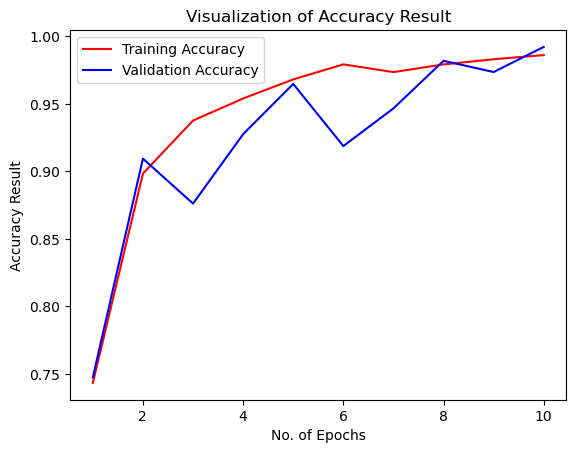

In [37]:
epochs = [i for i in range (1,11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

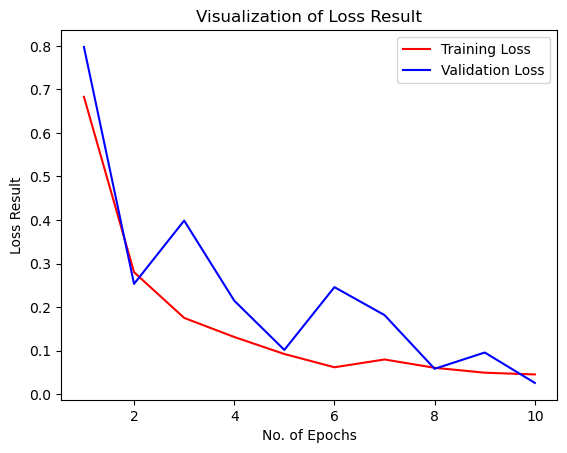

In [38]:
epochs = [i for i in range (1,11)]
plt.plot(epochs, training_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, training_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss Result")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [39]:
class_name = validation_set.class_names
class_name

['Anthracnose',
 'algal leaf',
 'bird eye spot',
 'brown blight',
 'gray light',
 'healthy',
 'red leaf spot',
 'white spot']

In [40]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 4188 files belonging to 8 classes.


In [41]:
y_pred = model.predict(test_set)
y_pred, y_pred.shape

131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step


(array([[9.9509287e-01, 2.7325255e-05, 3.7768581e-03, ..., 8.8528674e-07,
         1.1226487e-06, 3.6752429e-06],
        [9.9509287e-01, 2.7325255e-05, 3.7768581e-03, ..., 8.8528674e-07,
         1.1226487e-06, 3.6752429e-06],
        [9.9880224e-01, 1.1671274e-05, 2.1006521e-04, ..., 4.1113569e-07,
         5.8403299e-07, 2.5364473e-06],
        ...,
        [1.6655527e-05, 4.4490639e-02, 5.1049556e-06, ..., 7.4184602e-05,
         7.0817216e-05, 5.7799888e-01],
        [3.2039159e-05, 8.5238296e-01, 1.0588887e-05, ..., 2.6225860e-04,
         1.7827506e-03, 9.7043246e-02],
        [3.2039159e-05, 8.5238296e-01, 1.0588887e-05, ..., 2.6225860e-04,
         1.7827506e-03, 9.7043246e-02]], shape=(4188, 8), dtype=float32),
 (4188, 8))

In [42]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(4188,), dtype=int64, numpy=array([0, 0, 0, ..., 7, 1, 1], shape=(4188,))>

In [43]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(4188, 8), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(4188, 8), dtype=float32)>

In [44]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(4188,), dtype=int64, numpy=array([0, 0, 0, ..., 7, 7, 7], shape=(4188,))>

In [47]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 4.8 MB/s  0:00:01m 4.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 6.3 MB/s  0:00:03m 6.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn]0m 4/5 [scikit-learn]


In [48]:
from sklearn.metrics import classification_report, confusion_matrix

In [49]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

               precision    recall  f1-score   support

  Anthracnose       0.95      0.84      0.89       578
   algal leaf       0.98      1.00      0.99       472
bird eye spot       0.93      1.00      0.96       470
 brown blight       1.00      0.97      0.98       420
   gray light       0.96      0.94      0.95       702
      healthy       0.96      1.00      0.98      1022
red leaf spot       1.00      1.00      1.00       472
   white spot       0.83      0.96      0.89        52

     accuracy                           0.96      4188
    macro avg       0.95      0.96      0.96      4188
 weighted avg       0.96      0.96      0.96      4188



In [50]:
cm = confusion_matrix(Y_true, predicted_categories)
cm

array([[ 486,    0,   36,    0,   26,   30,    0,    0],
       [   0,  472,    0,    0,    0,    0,    0,    0],
       [   2,    0,  468,    0,    0,    0,    0,    0],
       [   0,    4,    0,  406,    0,    0,    0,   10],
       [  22,    2,    0,    0,  660,   18,    0,    0],
       [   0,    0,    0,    0,    0, 1022,    0,    0],
       [   0,    0,    0,    0,    0,    0,  472,    0],
       [   0,    2,    0,    0,    0,    0,    0,   50]])

## Confusion Matrix Visualiation

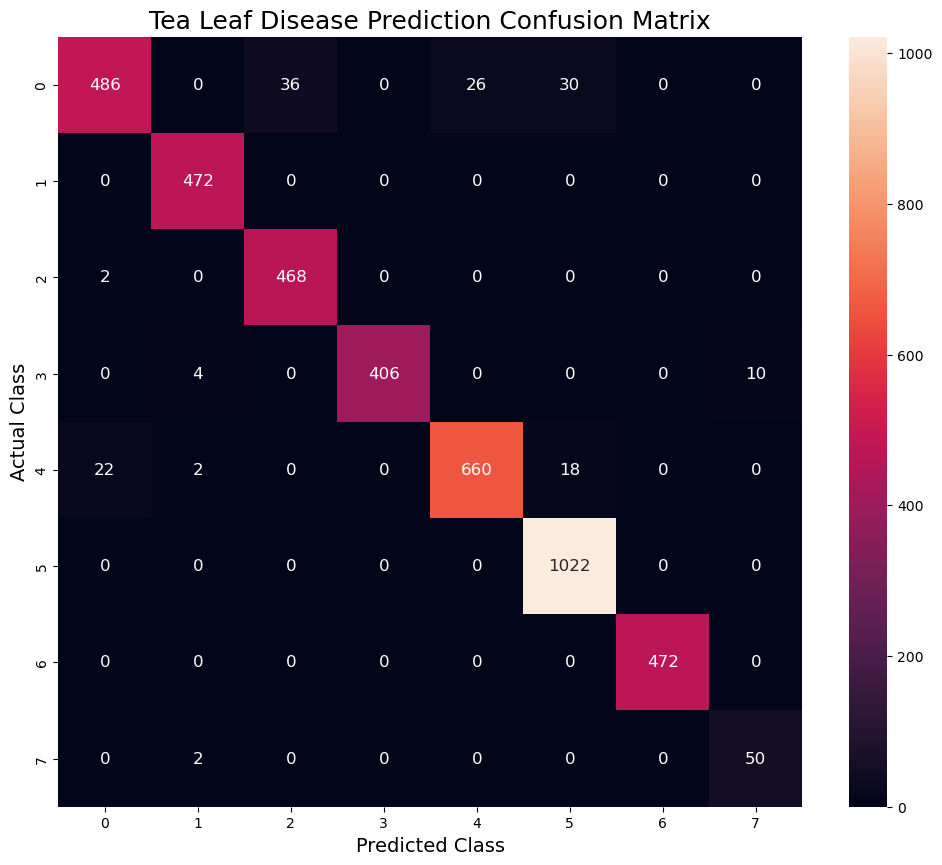

In [51]:
plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    annot_kws={"size": 12}
)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Actual Class", fontsize=14)
plt.title("Tea Leaf Disease Prediction Confusion Matrix", fontsize=18)
plt.show()